## Decision tree

In [2]:
from collections import Counter, defaultdict
from typing import List, Dict, Literal, Union
import re
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [3]:
os.environ["PYTHONHASHSEED"] = "42"
np.random.seed(42)
random.seed(42)
print("Seed: 42")

Seed: 42


In [4]:
df = pd.read_csv("D:/Code/Machine-Learning/Data/pj2/Heart_disease_cleveland_new.csv")

In [5]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(242, 13) (61, 13)
(242,) (61,)


In [6]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

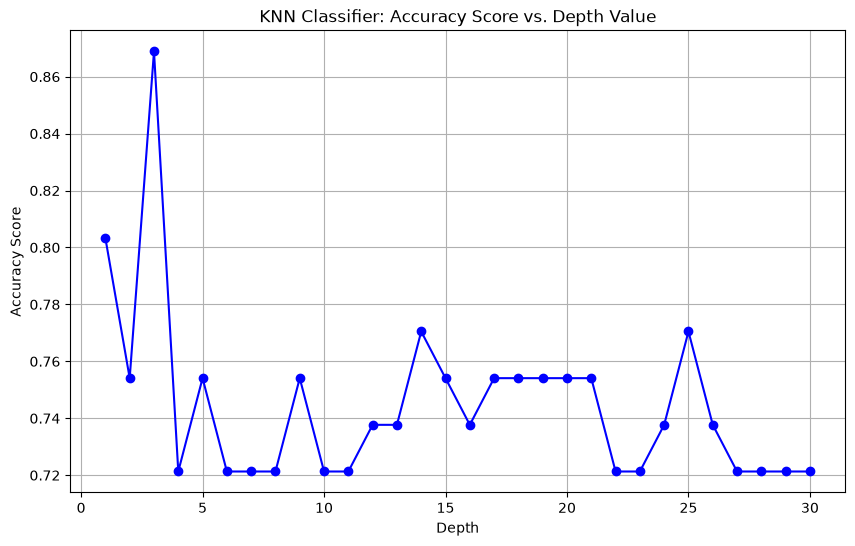

In [22]:
depth_values = [value for value in range(1,31)]

scores = []
for depth in depth_values:
    dt_classifier = DecisionTreeClassifier(max_depth=depth)
    dt_classifier.fit(X_train, y_train)
    pred = dt_classifier.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    scores.append(accuracy)
    
plt.figure(figsize=(10, 6))
plt.plot(depth_values, scores, marker='o', linestyle='-', color='b')
plt.title('KNN Classifier: Accuracy Score vs. Depth Value')
plt.xlabel('Depth')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.show()

In [23]:
optimal_depth = depth_values[np.argmax(scores)]
dt_classifier = DecisionTreeClassifier(max_depth=optimal_depth)
dt_classifier.fit(X_train, y_train)

pred = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 86.89%
